In [1]:
from pylmd import lmd, utils, cluster, plot
import scanpy as sc
import numpy as np
import pandas as pd
import sys
import os
import time
import pooch
import scipy.sparse as sp
from scipy.stats import entropy as sen
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import re
import seaborn as sns
import warnings

In [2]:
device = 'gpu'
max_time = 2**5

In [3]:
device_libs = lmd.get_xp(device)

In [4]:
xsc = device_libs['xsc']

In [5]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

path = EXAMPLE_DATA.fetch('s1d1_filtered_feature_bc_matrix.h5')

In [6]:
adata = sc.read_10x_h5(path)

/opt/conda/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/conda/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
adata.var_names_make_unique()

In [8]:
xsc.get.anndata_to_GPU(adata)

In [9]:
xsc.pp.filter_cells(adata, min_genes=100)
xsc.pp.filter_genes(adata, min_cells=3)

filtered out 72 cells that have less than 100 genes expressed
filtered out 14926 genes that are detected in less than 3 cells


In [10]:
raw_adata = adata.copy()

In [11]:
dat = pd.DataFrame(
    raw_adata.X.get().T.toarray() if not isinstance(raw_adata.X, np.ndarray) else raw_adata.X.T,
    index=adata.var_names,       # genes
    columns=adata.obs_names      # cells
)

In [12]:
xsc.pp.normalize_total(adata)
xsc.pp.log1p(adata)
xsc.pp.highly_variable_genes(adata, n_top_genes=2000)
xsc.pp.scale(adata,max_value=10)
xsc.tl.pca(adata)
xsc.get.anndata_to_CPU(adata)
xsc.pp.neighbors(adata)
xsc.tl.umap(adata)

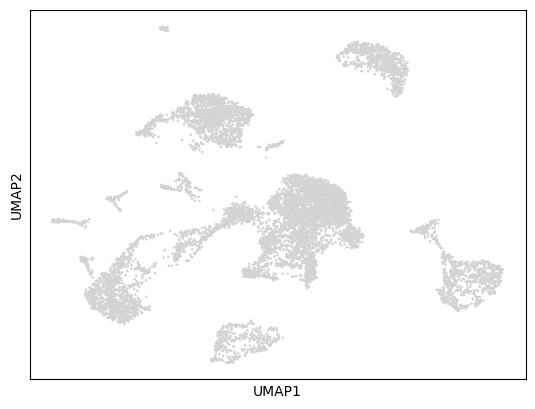

In [13]:
sc.pl.umap(adata)

In [14]:
cell_medians = np.median(dat, axis=0)
mask = dat > cell_medians

gene_detected_count = mask.sum(axis=1)

selected_genes = (gene_detected_count >= 10) & (gene_detected_count <= dat.shape[1] * 0.3)

In [15]:
adata = adata[:, selected_genes].copy()
raw_adata = raw_adata[:, selected_genes].copy()
dat = dat[selected_genes]

In [41]:
adata

AnnData object with n_obs × n_vars = 8713 × 16952
    obs: 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [16]:
feature_space = adata.obsm['X_pca'][:, :20]

In [17]:
W = lmd.build_network(feature_space, n_neighbors=5)

In [43]:
W

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 66864 stored elements and shape (8713, 8713)>

(<Figure size 800x800 with 1 Axes>, <Axes: >)

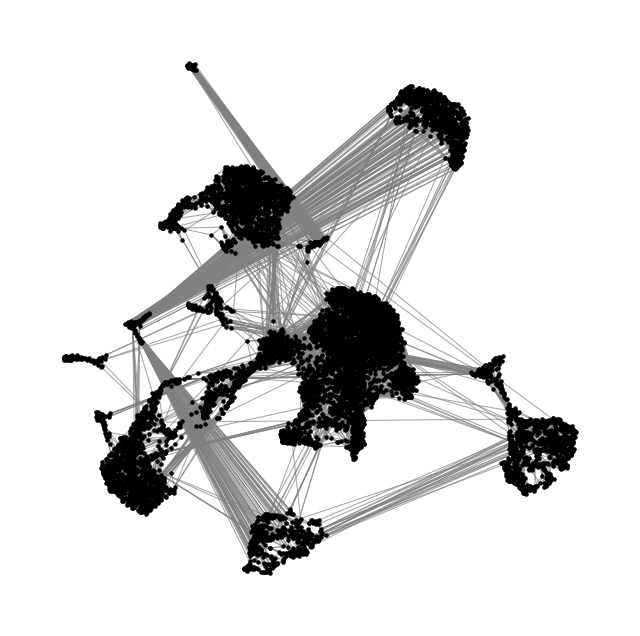

In [18]:
plot.visualize_network(W, adata)

In [19]:
rho = lmd.rowwise_normalize(dat, W)

In [44]:
rho

,AAACCCAAGGATGGCT-1,AAACCCAAGGCCTAGA-1,AAACCCAAGTGAGTGC-1,AAACCCACAAGAGGCT-1,AAACCCACATCGTGGC-1,AAACCCACATTCTCTA-1,AAACCCAGTCCGCAGT-1,AAACCCAGTGCATACT-1,AAACCCAGTTGACGGA-1,AAACCCATCGATACTG-1,...,TTTGTTGAGCTTACGT-1,TTTGTTGAGGGATCGT-1,TTTGTTGAGGTTACCT-1,TTTGTTGAGTAGTCCT-1,TTTGTTGAGTCTAGAA-1,TTTGTTGCAAATCAGA-1,TTTGTTGCACGCCACA-1,TTTGTTGCATAGGAGC-1,TTTGTTGCATTCGATG-1,TTTGTTGGTCACTCAA-1
AL627309.1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AL627309.5,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
LINC01409,0.0,0.000000,0.0,0.002079,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
LINC01128,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000841,0.0,0.0,0.0
LINC00115,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.001642,...,0.0,0.001642,0.001642,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC240274.1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC004556.3,0.0,0.000922,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000922,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC233755.1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [20]:
P_ls = lmd.construct_diffusion_operators(W, device_libs, max_time=max_time)

Creating diffusion operators...
Step 1: max deviation from convergence = 8713.0
Step 2: max deviation from convergence = 25809436.0
Step 3: max deviation from convergence = 10944500.0
Step 4: max deviation from convergence = 7396620.0
Step 5: max deviation from convergence = 5266180.5
Max diffusion time: 32
Total operators created: 6


In [45]:
P_ls

{0: <cupyx.scipy.sparse._csr.csr_matrix at 0x7f03ed199910>,
 2: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f03ed19a930>,
 4: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f0423d68590>,
 8: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f03ed19aa80>,
 16: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f03ed19ac00>,
 32: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f03ed19ac30>}

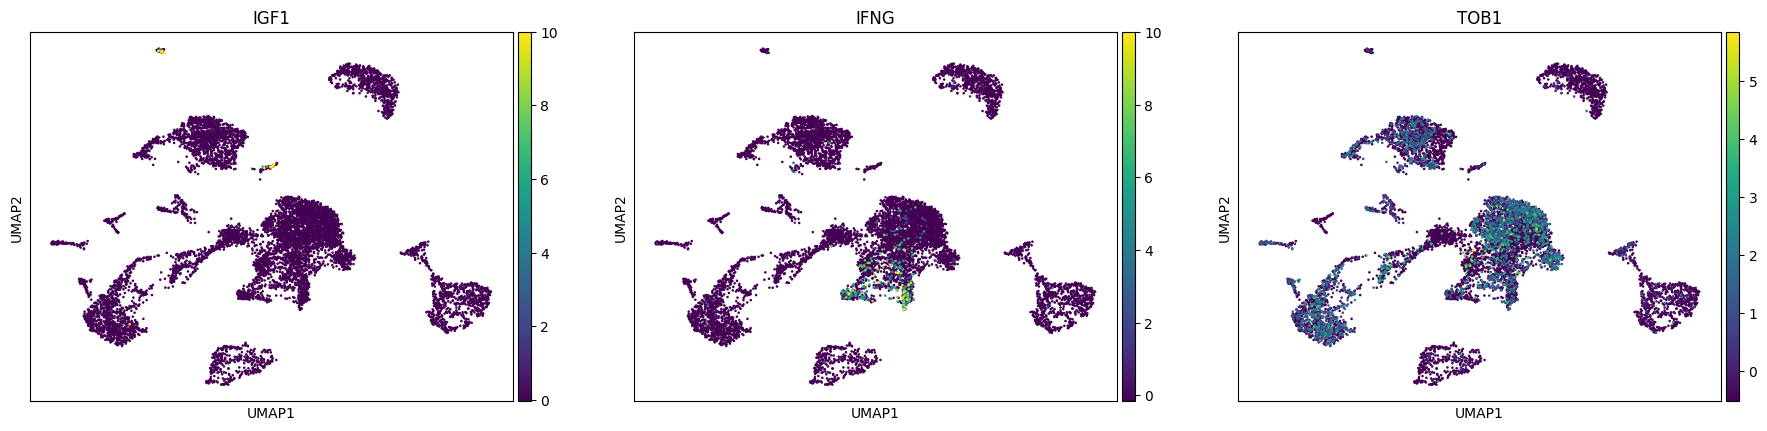

In [21]:
sc.pl.umap(adata, color = ['IGF1','IFNG','TOB1'])

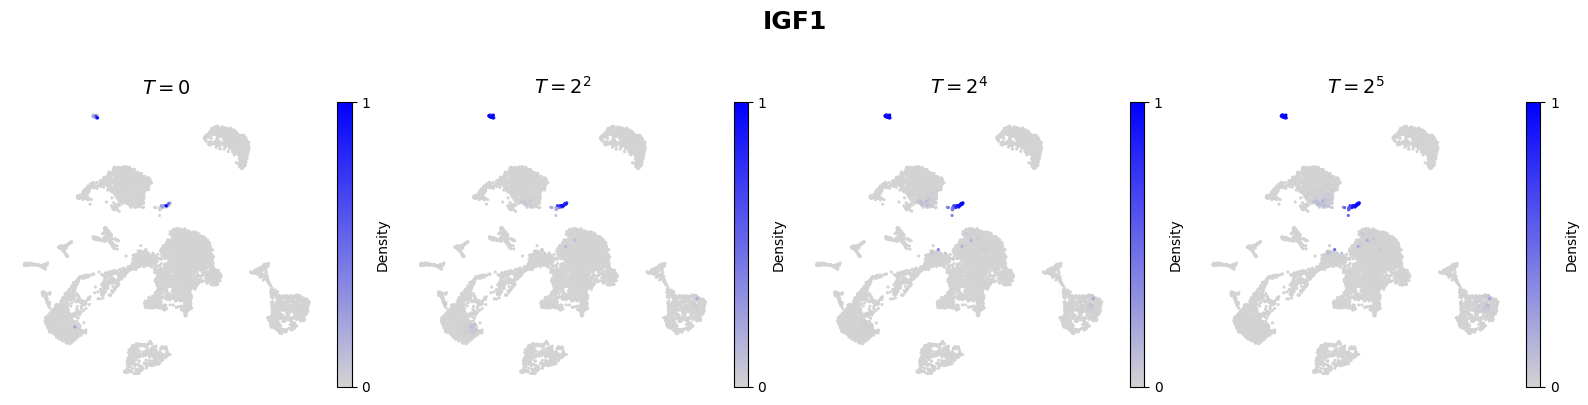

In [22]:
fig, axes = plot.visualize_diffusion(adata, rho, P_ls, 'IGF1')

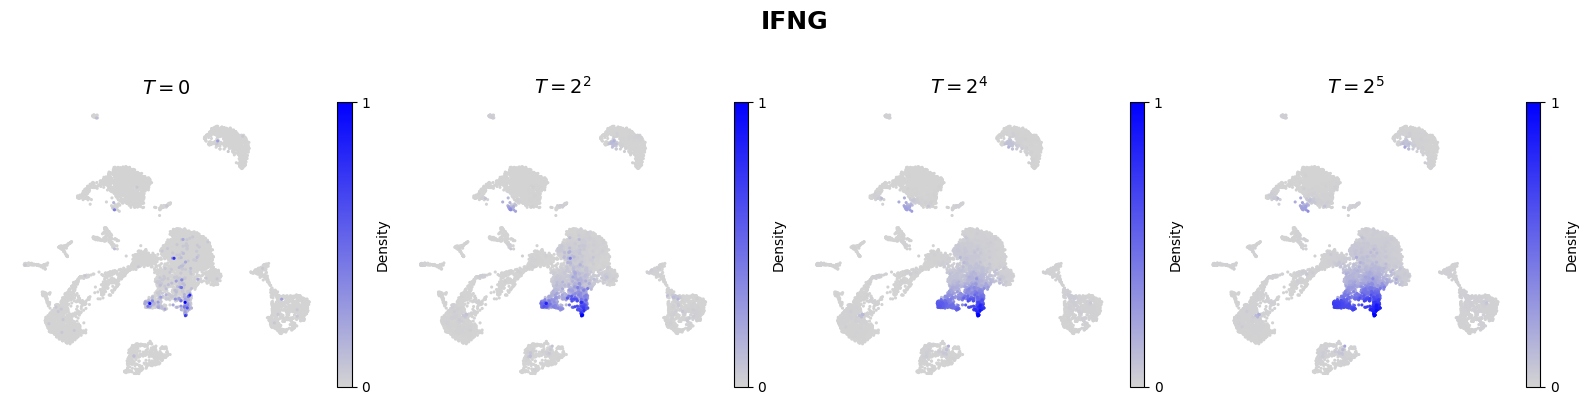

In [23]:
fig, axes = plot.visualize_diffusion(adata, rho, P_ls, 'IFNG')

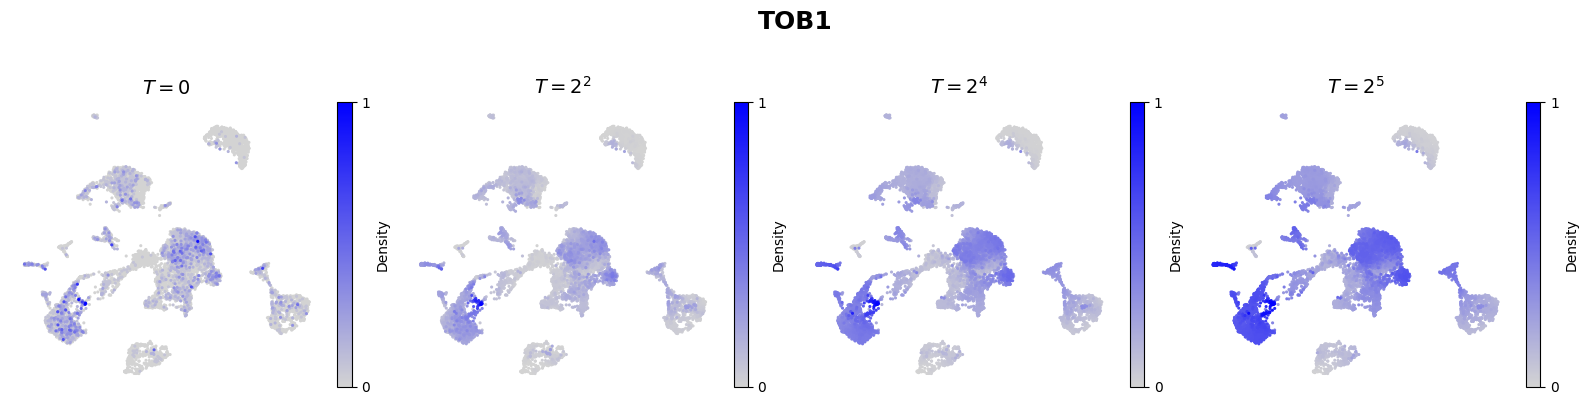

In [24]:
fig, axes = plot.visualize_diffusion(adata, rho, P_ls, 'TOB1')

In [25]:
score_df = lmd.calculate_score_profile(W, rho, P_ls, device_libs)

Completed scoring for time 0
Completed scoring for time 2
Completed scoring for time 4
Completed scoring for time 8
Completed scoring for time 16
Completed scoring for time 32


In [46]:
score_df

,0_0,0_2,0_4,0_8,0_16,0_32,0
AL627309.1,0.0,1.828948,2.791358,3.857164,4.659682,5.145946,5.853700
AL627309.5,0.0,1.674847,2.382705,2.985025,3.338952,3.511841,4.526448
LINC01409,0.0,1.483764,2.022780,2.418192,2.606418,2.703040,3.031843
LINC01128,0.0,1.006263,1.309046,1.512206,1.603367,1.648974,2.359099
LINC00115,0.0,1.736224,2.529843,3.279760,3.723930,3.915089,4.192639
...,...,...,...,...,...,...,...
AL592183.1,0.0,1.335490,1.789288,2.107244,2.260722,2.358647,2.787117
AC240274.1,0.0,1.744065,2.601721,3.462709,4.008635,4.263977,4.810540
AC004556.3,0.0,1.030028,1.336188,1.551586,1.681898,1.787848,2.458467
AC233755.1,0.0,1.661047,2.261656,2.836627,3.320771,3.733104,6.014232


In [26]:
norm_scores, lmd_scores = lmd.obtain_lmds(score_df)

In [47]:
norm_scores

,0_0,0_2,0_4,0_8,0_16,0_32
AL627309.1,0.0,0.312443,0.476854,0.658927,0.796023,0.879093
AL627309.5,0.0,0.370014,0.526396,0.659463,0.737654,0.775849
LINC01409,0.0,0.489393,0.667178,0.797598,0.859681,0.891550
LINC01128,0.0,0.426546,0.554892,0.641010,0.679652,0.698985
LINC00115,0.0,0.414113,0.603401,0.782266,0.888207,0.933801
...,...,...,...,...,...,...
AL592183.1,0.0,0.479165,0.641985,0.756066,0.811133,0.846268
AC240274.1,0.0,0.362551,0.540838,0.719817,0.833302,0.886382
AC004556.3,0.0,0.418972,0.543504,0.631119,0.684125,0.727221
AC233755.1,0.0,0.276186,0.376051,0.471652,0.552152,0.620712


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Gene Scores Over Time'}, xlabel='Time', ylabel='Normalized Diffusion KL Score'>)

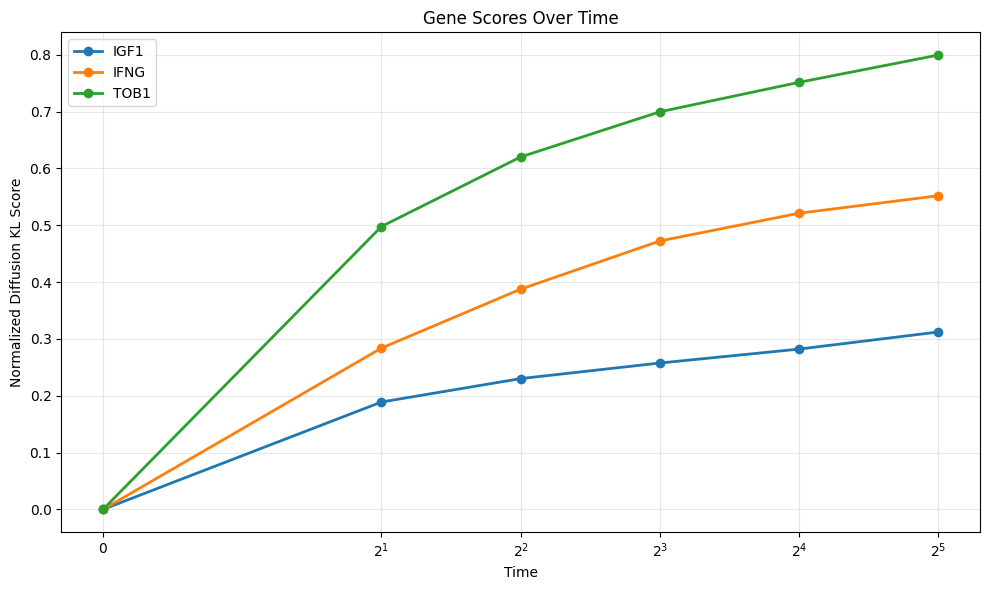

In [27]:
plot.visualize_score_pattern(norm_scores, genes = ['IGF1','IFNG','TOB1'])

In [28]:
sort_score = lmd_scores.sort_values()

In [29]:
sort_score[:10]

LILRA4    0.344978
GZMB      0.449992
SLC4A1    0.463193
SNCA      0.481462
ALAS2     0.494492
GYPA      0.511611
HEMGN     0.518800
RHAG      0.568625
S100A8    0.575408
GYPB      0.578457
Name: LMDS, dtype: float32

In [30]:
sort_score[int(len(sort_score)-10):]

ZNF394     3.995993
MAP2K7     4.002942
SENP7      4.007152
RETREG3    4.011299
ANKZF1     4.016985
CRTC2      4.017739
PLCL2      4.030200
ZNF335     4.041975
KHNYN      4.055999
ST3GAL1    4.063762
Name: LMDS, dtype: float32

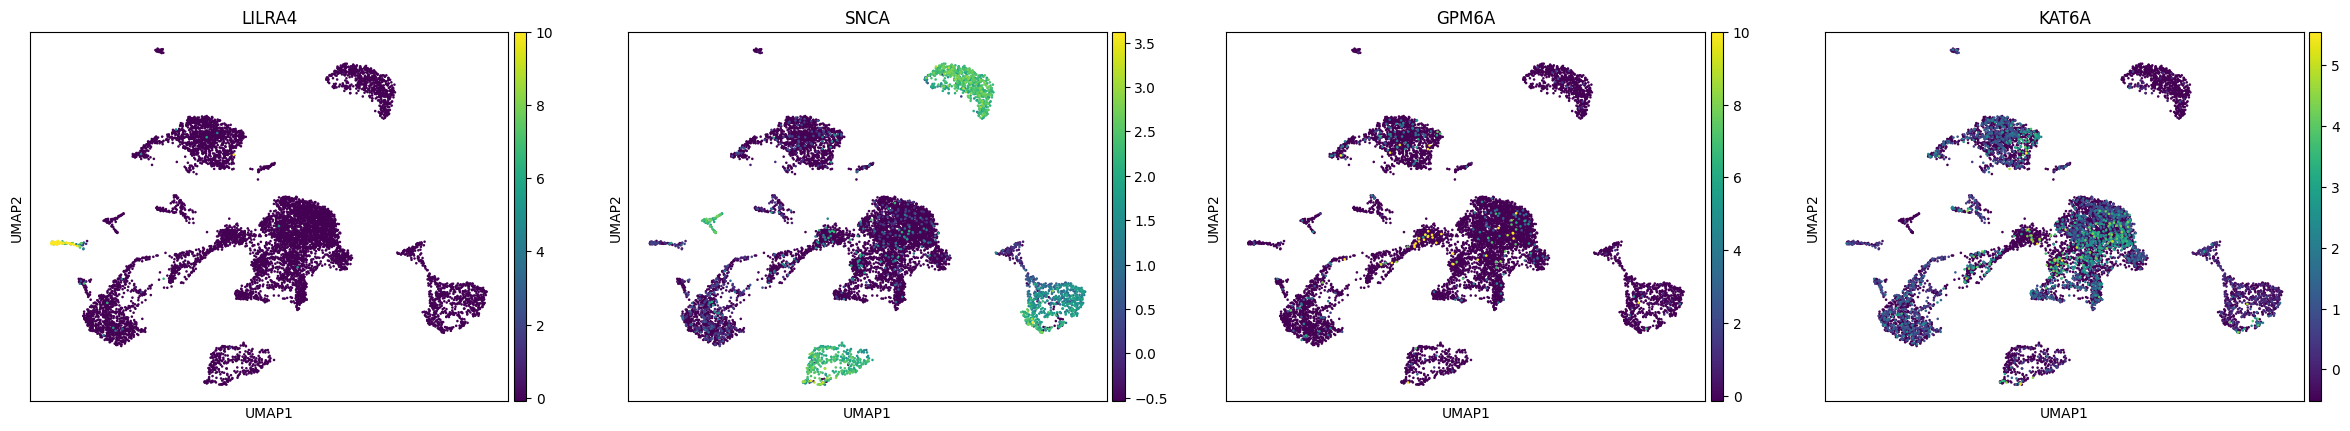

In [31]:
sc.pl.umap(adata, color = ['LILRA4', 'SNCA', 'GPM6A', 'KAT6A'])

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Gene Scores Over Time'}, xlabel='Time', ylabel='Normalized Diffusion KL Score'>)

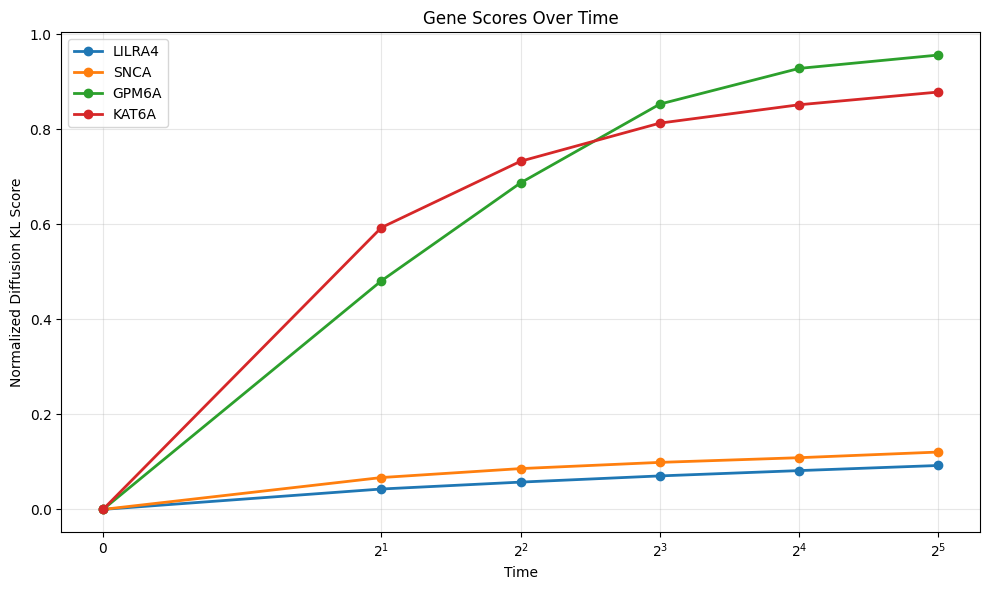

In [32]:
plot.visualize_score_pattern(norm_scores, genes = ['LILRA4', 'SNCA', 'GPM6A', 'KAT6A'])

In [33]:
knee = lmd.find_knee(lmd_scores)

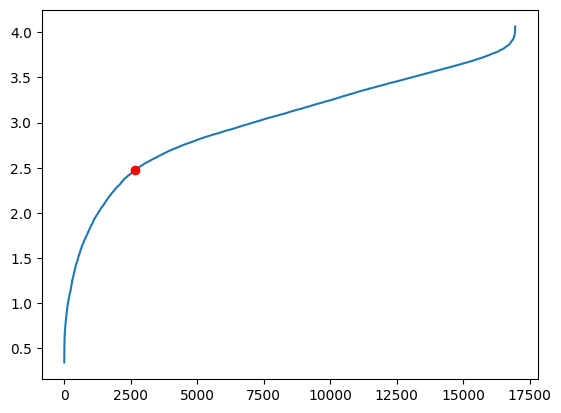

In [34]:
plt.plot(sorted(lmd_scores))
plt.plot(knee, sorted(lmd_scores)[knee], 'ro')

plt.show()

In [35]:
LMDs = list(lmd_scores.sort_values()[:knee].index)

In [49]:
LMDs[:10]

['LILRA4',
 'GZMB',
 'SLC4A1',
 'SNCA',
 'ALAS2',
 'GYPA',
 'HEMGN',
 'RHAG',
 'S100A8',
 'GYPB']

In [36]:
lmd_dat = dat[dat.index.isin(LMDs)]

In [37]:
dist = cluster.distance(lmd_dat, method = 'jaccard')

In [38]:
gene_sets = cluster.modules(dist, clustering_method = "average", min_gene = 10, deepSplit = 2)

..cutHeight not given, setting it to 0.9939070137573984  ===>  99% of the (truncated) height range in dendro.
..done.


/notebooks/pylmd/pylmd/pylmd/cluster.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_pos = (gene_partition.index.to_series().map(label_pos).groupby(gene_partition).median().sort_values())
/notebooks/pylmd/pylmd/pylmd/cluster.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_sets = gene_partition.groupby(gene_partition).apply(lambda x: x.index.tolist()).to_dict()


In [51]:
gene_sets.keys()

dict_keys([4, 12, 13, 14, 15, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 33, 34, 38, 39])

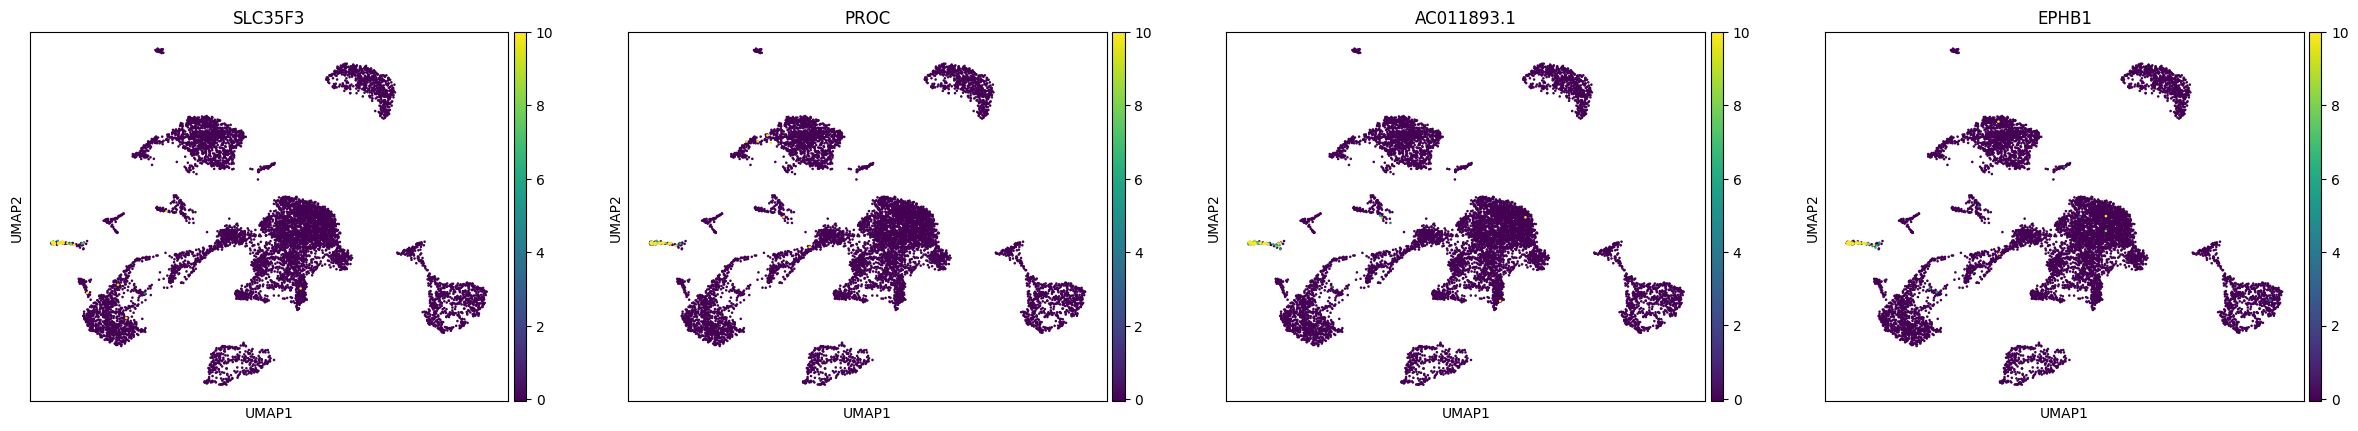

In [52]:
sc.pl.umap(adata, color = gene_sets[4][0:4])

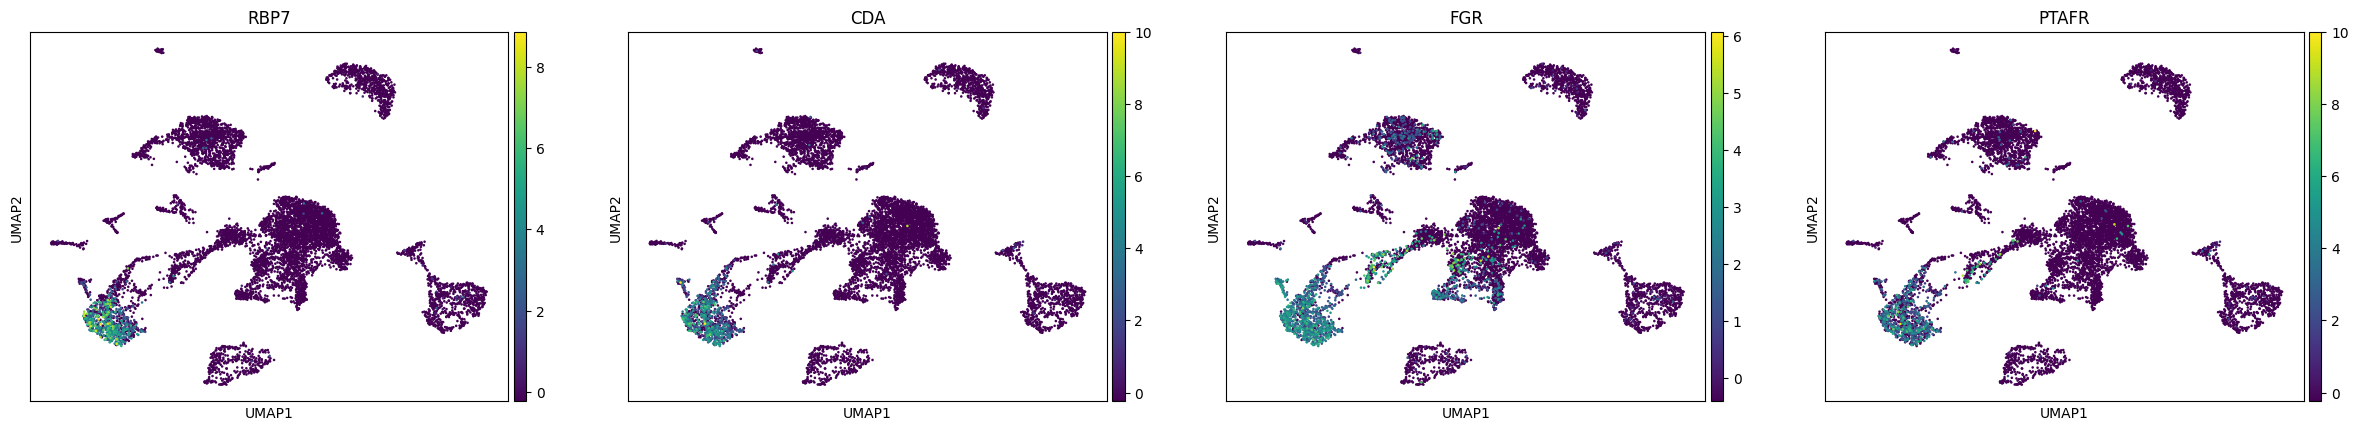

In [53]:
sc.pl.umap(adata, color = gene_sets[12][0:4])

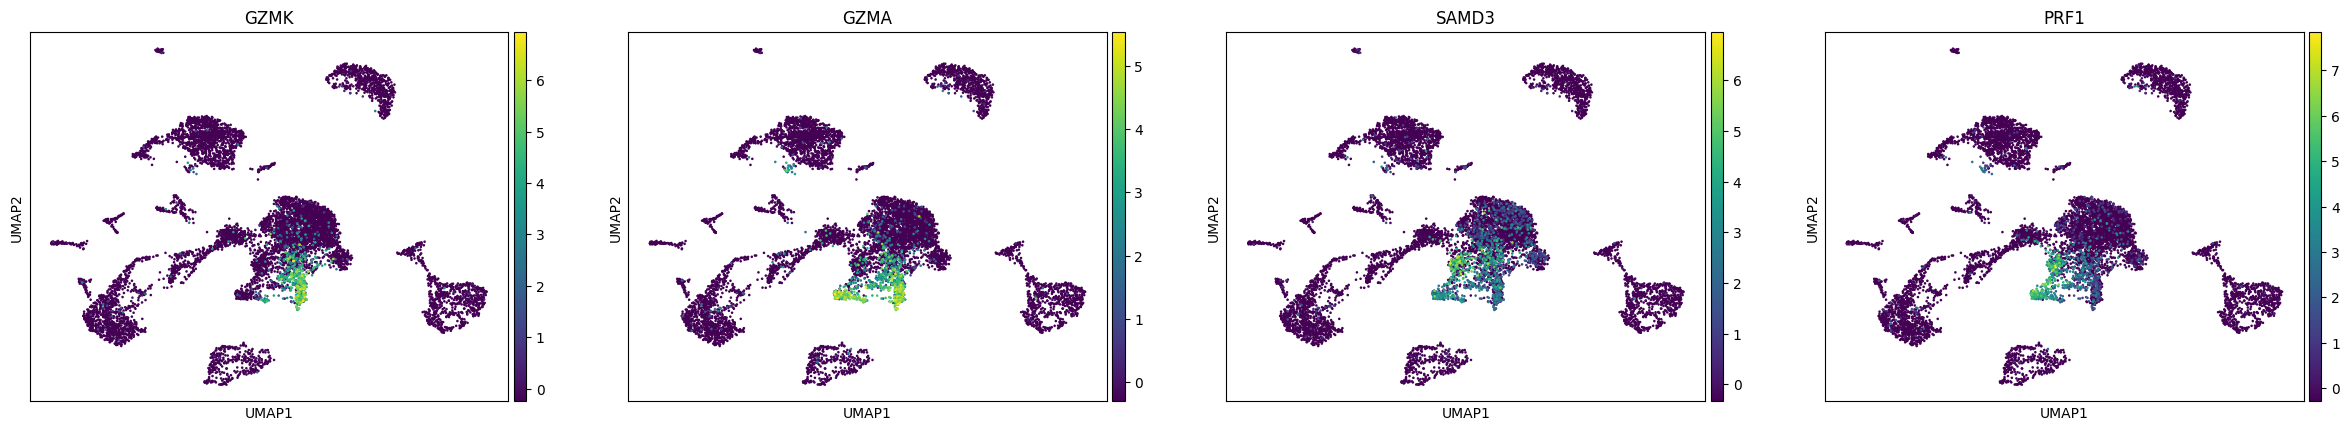

In [54]:
sc.pl.umap(adata, color = gene_sets[34][0:4])